# Data Script für die Finanzübersicht


# Daten laden - Finanzdaten

In [75]:
#pip install numpy

In [76]:
#pip install matplotlib

In [77]:
#pip install requests

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import lxml
#import plotly.express as px
#import plotly.graph_objects as go
#import plotly.figure_factory as ff

In [79]:
url="https://artstudio-mayer.de/finanzen/"
html = requests.get(url).text

In [80]:
tables = pd.read_html(html)

In [81]:
Finanzen_Tablepress = tables[0]

In [82]:
Finanzen_Tablepress

,Kategorie,Posten,Maße,Datum,Saldo,Einnahme,Ausgabe,Menge,Klassifizierung,Notiz,Rechnungen
0,Ausgaben,Einkauf Amazon,NaN,21.02.2024,"62,00 €",– €,"62,00 €",NaN,Amazon,Ringlicht mit Stativ,NaN
1,Einnahmen,Unnamed,70cm x 50cm,24.02.2024,"71,00 €","71,00 €",– €,1.0,Freunde/Bekannte,Verkauf an Stefan Uebelacker,NaN
2,Einnahmen,Unnamed,50cm x 40cm,27.02.2024,"45,00 €","45,00 €",– €,1.0,Freunde/Bekannte,Verkauf an Maximilian Mittermeier,NaN
3,Ausgaben,Einkauf Action,NaN,21.03.2024,"5,98 €",– €,"5,98 €",NaN,Action,Bilderrahmen,NaN
4,Ausgaben,Einkauf Jysk,NaN,21.03.2024,"49,50 €",– €,"49,50 €",NaN,Jysk,Bilderrahmen,NaN
...,...,...,...,...,...,...,...,...,...,...,...
126,Einnahmen,Krümmung,50cm x 40cm,18.06.2026,"50,00 €","50,00 €",NaN,1.0,Ausstellung,Café Luibl (Verkauf über Website),NaN
127,Ausgaben,Einkauf Amazon,NaN,23.06.2026,"179,95 €",NaN,"179,95 €",0.0,Amazon,Leinwand auf Amazon,NaN
128,Ausgaben,Einkauf Action,NaN,25.06.2026,"12,61 €",NaN,"12,61 €",0.0,Action,Einkauf Farbe,NaN
129,Ausgaben,Einkauf Action,NaN,18.07.2026,"2,99 €",NaN,"2,99 €",0.0,Action,Einkauf Farbe,NaN


# Daten laden - Produktion

In [83]:
Produktion_Tablepress = tables[1]

In [84]:
#Produktion_Tablepress

In [85]:
# (Produktion_Tablepress
# .groupby('Jahr')
# .agg(Menge=('Anzahl', 'sum'))
# .reset_index().sort_values('Jahr')
# .tail(3))

# Datenbereinigung - Finanzdaten

In [86]:
# Datenbereinigung

Finanzen_Tablepress["Maße"] = Finanzen_Tablepress["Maße"].fillna("")

# Ensure Menge is numeric (float) and fill NaN with 0
Finanzen_Tablepress["Menge"] = pd.to_numeric(Finanzen_Tablepress["Menge"], errors='coerce').fillna(0)

In [87]:
# Datum formatieren

Finanzen_Tablepress["Datum"] = pd.to_datetime(
    Finanzen_Tablepress["Datum"],
    format="%d.%m.%Y",
    errors="coerce"
)

In [88]:
# Spalte "Jahr" aus Datum extrahieren und extra Spalte erstellen

Finanzen_Tablepress["Jahr"] = Finanzen_Tablepress["Datum"].dt.year

In [89]:
# Bereinigung der Spalte "Saldo"

def bereinige_saldo(wert):
    try:
        bereinigt = str(wert).replace("€", "").replace(",", ".").replace("–", "").strip()
        return float(bereinigt) if bereinigt else None
    except:
        return None

Finanzen_Tablepress['Saldo'] = Finanzen_Tablepress['Saldo'].apply(bereinige_saldo).fillna(0) # Changed fillna("0") to fillna(0)

In [90]:
# Bereinigung der Spalte "Einnahmen"

def bereinige_einnahme(wert):
    try:
        bereinigt = str(wert).replace("€", "").replace(",", ".").replace("–", "").strip()
        return float(bereinigt) if bereinigt else None
    except:
        return None

Finanzen_Tablepress['Einnahme'] = Finanzen_Tablepress['Einnahme'].apply(bereinige_einnahme).fillna(0) # Changed fillna("0") to fillna(0)

In [91]:
# Bereinigung der Spalte "Ausgabe"

def bereinige_ausgabe(wert):
    try:
        bereinigt = str(wert).replace("€", "").replace(",", ".").replace("–", "").strip()
        return float(bereinigt) if bereinigt else None
    except:
        return None

Finanzen_Tablepress['Ausgabe'] = Finanzen_Tablepress['Ausgabe'].apply(bereinige_ausgabe).fillna(0) # Changed fillna("0") to fillna(0)

In [92]:
Finanzen_Tablepress

,Kategorie,Posten,Maße,Datum,Saldo,Einnahme,Ausgabe,Menge,Klassifizierung,Notiz,Rechnungen,Jahr
0,Ausgaben,Einkauf Amazon,,2024-02-21,62.00,0.0,62.00,0.0,Amazon,Ringlicht mit Stativ,NaN,2024
1,Einnahmen,Unnamed,70cm x 50cm,2024-02-24,71.00,71.0,0.00,1.0,Freunde/Bekannte,Verkauf an Stefan Uebelacker,NaN,2024
2,Einnahmen,Unnamed,50cm x 40cm,2024-02-27,45.00,45.0,0.00,1.0,Freunde/Bekannte,Verkauf an Maximilian Mittermeier,NaN,2024
3,Ausgaben,Einkauf Action,,2024-03-21,5.98,0.0,5.98,0.0,Action,Bilderrahmen,NaN,2024
4,Ausgaben,Einkauf Jysk,,2024-03-21,49.50,0.0,49.50,0.0,Jysk,Bilderrahmen,NaN,2024
...,...,...,...,...,...,...,...,...,...,...,...,...
126,Einnahmen,Krümmung,50cm x 40cm,2026-06-18,50.00,50.0,0.00,1.0,Ausstellung,Café Luibl (Verkauf über Website),NaN,2026
127,Ausgaben,Einkauf Amazon,,2026-06-23,179.95,0.0,179.95,0.0,Amazon,Leinwand auf Amazon,NaN,2026
128,Ausgaben,Einkauf Action,,2026-06-25,12.61,0.0,12.61,0.0,Action,Einkauf Farbe,NaN,2026
129,Ausgaben,Einkauf Action,,2026-07-18,2.99,0.0,2.99,0.0,Action,Einkauf Farbe,NaN,2026


In [93]:
#Finanzen_Tablepress.to_excel("output.xlsx", index=False)

# Merge Finanzdaten und Produktionsdaten

***Promt zur Ergänzung der Summe der gemalten Bilder im Dataframe Finanzdaten_Tablepress:***

Ich habe den Dataframe Finanzen_Tablepress. Der Dataframe ist wie folgt aufgebaut:
1) Spalte 1 = Kategorie
2) Spalte 2 = Posten
3) Spalte 3 = Maße
4) Spalte 4 = Datum
5) Spalte 5 = Saldo
6) Spalte 6 = Einnahme
7) Spalte 7 = Ausgabe
8) Spalte 8 = Menge
9) Spalte 9 = Klassifizierung
10) Spalte 10 = Notiz
11) Spalte 11 = Rechnungen

Ich habe einen zweiten Dataframe Produktion_Tablepress. Der Dataframe ist wie folgt aufgebaut:
1) Spalte 1 = Jahr
2) Spalte 2 = Titel
3) Spalte 3 = Anzahl

Ich möchte im Dataframe "Finanzen_Tablepress" eine Spalte ergänzen. Der Name der Spalte soll "gemalte Bilder" lauten. Der Inhalt soll aus dem Dataframe "Produktion_Tablepress" gezogen werden
Gemalte Bilder["Finanzen_Tablepress"] = Summe der Spalte "Anzahl" aus dem Dataframe "Produktion_Tablepress" gruppiert nach Jahr

In [94]:
# Anzahl der gemalten Bilder pro Jahr summieren
gemalte_bilder = (
    Produktion_Tablepress
    .groupby("Jahr", as_index=False)["Anzahl"]
    .sum()
    .rename(columns={"Anzahl": "gemalte Bilder"})
)

# Jahr aus dem Datum in Finanzen_Tablepress bestimmen
Finanzen_Tablepress["Jahr"] = pd.to_datetime(
    Finanzen_Tablepress["Datum"]
).dt.year

# Summe der gemalten Bilder anhand des Jahres ergänzen
Finanzen_Tablepress = Finanzen_Tablepress.merge(
    gemalte_bilder,
    on="Jahr",
    how="left"
)

# Jahre ohne Produktion mit 0 füllen
Finanzen_Tablepress["gemalte Bilder"] = (
    Finanzen_Tablepress["gemalte Bilder"]
    .fillna(0)
    .astype(int)
)

In [95]:
#Finanzen_Tablepress

# Jahresübersicht

***Promt für die Erstellung der Tabelle:***

Ich möchte basierend auf diesem Dataframe eine Tabelle in Matplotlib erstellen. Die Tabelle soll folgenden Aufbau haben:

Spalten: Jahre (findest du in der Spalte "Jahre")
Zeilen:
1) Einnahmen = Summe der Spalte "Einnahme" gruppiert nach Jahr
2) Ausgaben = Summe der Spalte "Ausgaben" gruppiert nach Jahr
3) Gewinn = Summe der Spalte "Einnahme" gruppiert nach Jahr - Summe der Spalte "Ausgaben" gruppiert nach Jahr
4) Leerzeile
5) Verk. Bilder = Summe der Spalte "Menge" gruppiert nach Jahr
6) Avg. Preis = Summe der Spalte "Einnahme" gruppiert nach Jahr / Summe der Spalte "Menge" gruppiert nach Jahr
7) Leerzeile
8) Gemalte Bilder = Mittelwert der Spalte "gemalte Bilder" gruppiert nach Jahr
9) Avg. Kosten = Summe der Spalte "Ausgabe" gruppiert nach Jahr / Mittelwert der Spalte "gemalte Bilder" gruppiert nach Jahr

Zur Formatierung:
1) Dunkelgraue Rahmenlinien
2) Zeilenhöhe doppelt als Standard
3) Erste Spalte linksbündig
4) Erste Spalte und erste Zeile fettgedruckt

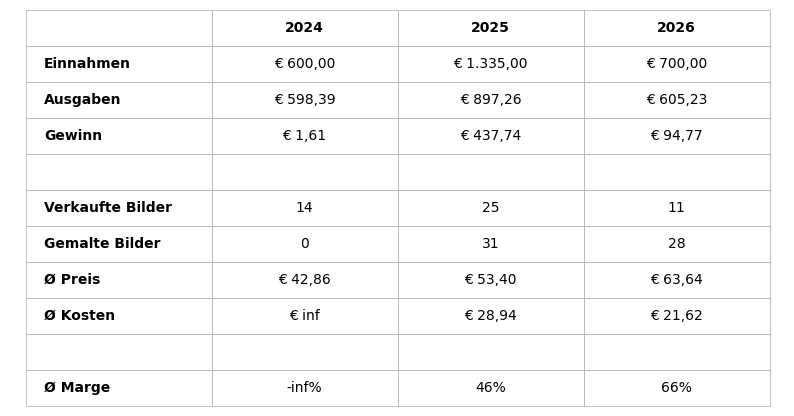

In [96]:
# Jahresübersicht
annual_summary = (
    Finanzen_Tablepress
    .groupby('Jahr')
    .agg(
        Einnahme=('Einnahme', 'sum'),
        Ausgabe=('Ausgabe', 'sum'),
        Menge=('Menge', 'sum'),
        Gemalte_Bilder=('gemalte Bilder', 'mean')
    )
    .reset_index()
    .sort_values('Jahr')  # Sortierung nach Jahr
    .tail(3)  # Ergebnis auf die letzten 3 Jahre begrenzen
)

# Gewinn
annual_summary['Gewinn'] = (
    annual_summary.Einnahme - annual_summary.Ausgabe
)

# Durchschnittliche Einnahmen pro verkauftem Bild
annual_summary['Ø Preis'] = (
    annual_summary.Einnahme / annual_summary.Menge
).fillna(0)

# Durchschnittliche Kosten pro gemaltem Bild
annual_summary['Ø Kosten'] = (
    annual_summary.Ausgabe / annual_summary.Gemalte_Bilder
).fillna(0)

# Durchschnittliche Marge pro Jahr
annual_summary['Ø Marge'] = (annual_summary['Ø Preis'] - annual_summary['Ø Kosten']) / annual_summary['Ø Preis'].fillna(0)


# Währungsformat
def euro(x):
    return f"€ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

years = annual_summary.Jahr.astype(str).tolist()

# Tabellendaten
table_data = [
    ['Einnahmen'] + annual_summary.Einnahme.map(euro).tolist(),
    ['Ausgaben'] + annual_summary.Ausgabe.map(euro).tolist(),
    ['Gewinn'] + annual_summary.Gewinn.map(euro).tolist(),
    [''] * (len(years) + 1),
    ['Verkaufte Bilder'] + annual_summary.Menge.astype(int).astype(str).tolist(),
    ['Gemalte Bilder'] + annual_summary.Gemalte_Bilder.astype(int).astype(str).tolist(),
    ['Ø Preis'] + annual_summary['Ø Preis'].map(euro).tolist(),
    ['Ø Kosten'] + annual_summary['Ø Kosten'].map(euro).tolist(),
    [''] * (len(years) + 1),
    ['Ø Marge'] + annual_summary['Ø Marge'].map(lambda x: f"{x:.0%}").replace(float("inf"), "n/a").tolist()
]

# Schriftart
#plt.rcParams['font.family'] = 'Verdana'

# Tabelle erstellen
fig_Jahresübersicht, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=[''] + years,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Zellen formatieren
cells = table.get_celld()

for (row, col), cell in cells.items():
    cell.set_edgecolor('darkgrey')
    cell.set_linewidth(0.5)

    if col == 0:
        cell.get_text().set_ha('left')

    if row == 0 or col == 0:
        cell.get_text().set_weight('bold')

# Zeilenhöhe verdoppeln
height = cells[(0, 0)].get_height()
for cell in cells.values():
    cell.set_height(height * 1.8)

# Spaltenbreite
width = cells[(0, 0)].get_width()
for cell in cells.values():
    cell.set_width(width * 0.8)

plt.show()

**Export in HTML Datei**



In [97]:
from io import StringIO
from matplotlib.backends.backend_svg import FigureCanvasSVG

svg = StringIO()
FigureCanvasSVG(fig_Jahresübersicht).print_svg(svg)

with open("Jahresübersicht.html", "w", encoding="utf-8") as f:
    f.write(f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Jahresübersicht</title>
    </head>
    <body>
        {svg.getvalue()}
    </body>
    </html>
    """)

# Umsatzstärkstes Quartal (seit 2024)

***Promt für die Erstellung des Balkendiagramms***

Hier ist der Code für meine Quartalsübersicht:
...

Ich möchte jetzt ein Balkendiagramm für das umsatzstärkste Quartal. Es soll nur vier Balken beinhalten und jeder Balken soll die Summe der jeweiligen Quartale der letzten 3 Jahre beinhalten. Beispiel: Balken 1 = Quartal 1 = Summe aus Q1 24 + Q1 25 + Q1 26 Erstelle mir dafür bitte den Code.

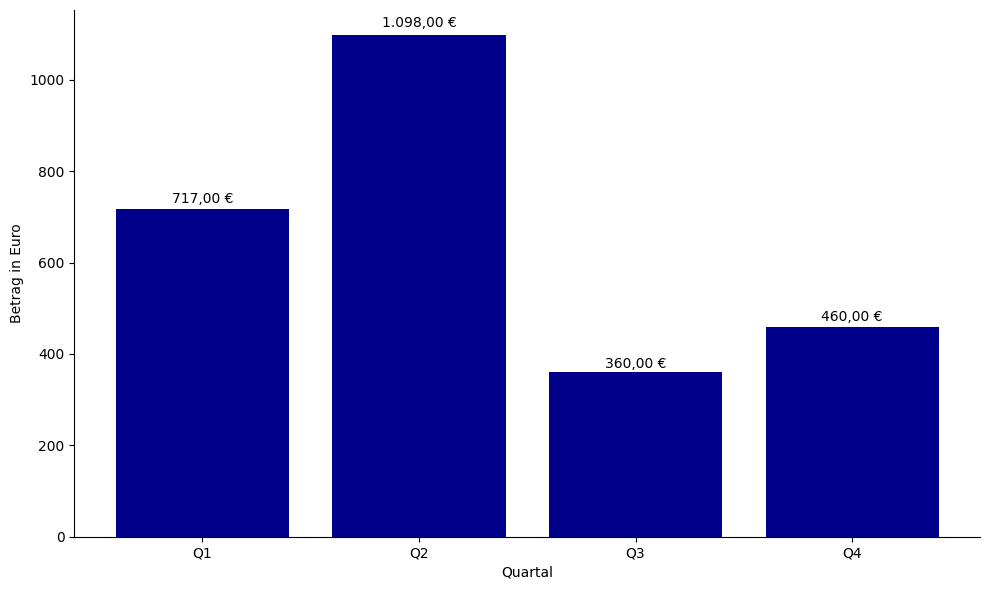

In [98]:
df = Finanzen_Tablepress.copy()

# Letzte 3 Jahre
df = df[df['Jahr'] >= df['Jahr'].max() - 2]

# Quartal bilden und Einnahmen über alle 3 Jahre summieren
einnahmen_quartal = (
    df.groupby(df['Datum'].dt.quarter)['Einnahme']
    .sum()
)

# Sicherstellen, dass Q1 bis Q4 vorhanden sind
einnahmen_quartal = einnahmen_quartal.reindex([1, 2, 3, 4], fill_value=0)

# Beschriftungen
labels = ['Q1', 'Q2', 'Q3', 'Q4']

# Diagramm
fig_Umsatzstärkstes_Quartal_summe, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels,
    einnahmen_quartal,
    color='darkblue'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('Betrag in Euro')
ax.set_xlabel('Quartal')

# Werte über den Balken
for bar, wert in zip(bars, einnahmen_quartal):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        wert + abs(wert) * 0.01,  # kleiner Abstand zum Balken
        f'{wert:,.2f} €'.replace(',', 'X').replace('.', ',').replace('X', '.'),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [99]:
svg = StringIO()
FigureCanvasSVG(fig_Umsatzstärkstes_Quartal_summe).print_svg(svg)

with open("Umsatzstärkstes_Quartal.html", "w", encoding="utf-8") as f:
    f.write(f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Umsatzstärkstes_Quartal</title>
    </head>
    <body>
        {svg.getvalue()}
    </body>
    </html>
    """)

#  Quartalsübersicht (letzte 3 Jahre)

***Promt für die Erstellung des Balkendiagramms***

Erstelle mir bitte auf Grundlage des Dataframes "Datengrundlage" ein Balkendiagramm für eine Quartalsübersicht. Das Balkendiagramm soll folgendes beinhalten:

1.   Y-Achse: Betrag in Euro
2.   X-Achse: Quartale der letzten 3 Jahre
3.   Angezeigter Wert pro Quartal: Summe der Spalte "Einnahme" gruppiert nach Quartal pro Jahr
4.   Benamung: Q1 JJ
5.   Farbe der Balken: dunkelblau

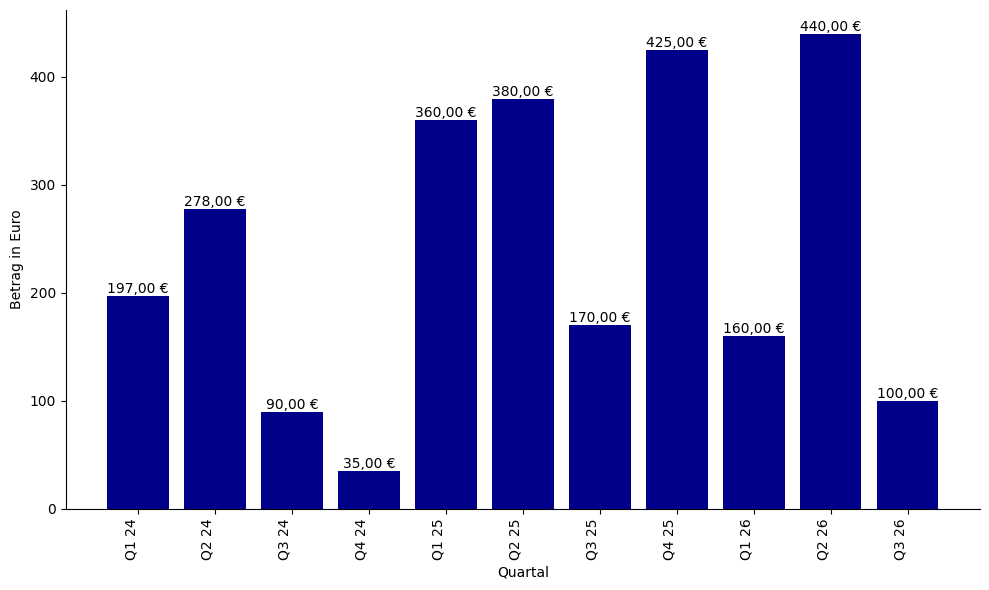

In [100]:
df = Finanzen_Tablepress.copy()

# Letzte 3 Jahr
df = df[df['Jahr'] >= df['Jahr'].max() - 2]

# Quartal bilden und Einnahmen summieren
einnahmen = (
    df.groupby([df['Datum'].dt.year, df['Datum'].dt.quarter])['Einnahme']
    .sum()
)

# Beschriftungen
labels = [f"Q{quartal} {str(jahr)[-2:]}" for jahr, quartal in einnahmen.index]

# Diagramm
fig_Quartal, ax = plt.subplots(figsize=(10, 6))
bars = plt.bar(labels, einnahmen, color='darkblue')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.ylabel('Betrag in Euro')
plt.xlabel('Quartal')
plt.xticks(rotation=90, ha='right')

# Werte über den Balken
for bar, wert in zip(bars, einnahmen):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        wert,
        f'{wert:,.2f} €'.replace(',', 'X').replace('.', ',').replace('X', '.'),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [101]:
from io import StringIO
from matplotlib.backends.backend_svg import FigureCanvasSVG

svg = StringIO()
FigureCanvasSVG(fig_Quartal).print_svg(svg)

with open("Quartalsübersicht.html", "w", encoding="utf-8") as f:
    f.write(f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Quartalsübersicht</title>
    </head>
    <body>
        {svg.getvalue()}
    </body>
    </html>
    """)

# Umsatzstärkster Monat (seit 2024)

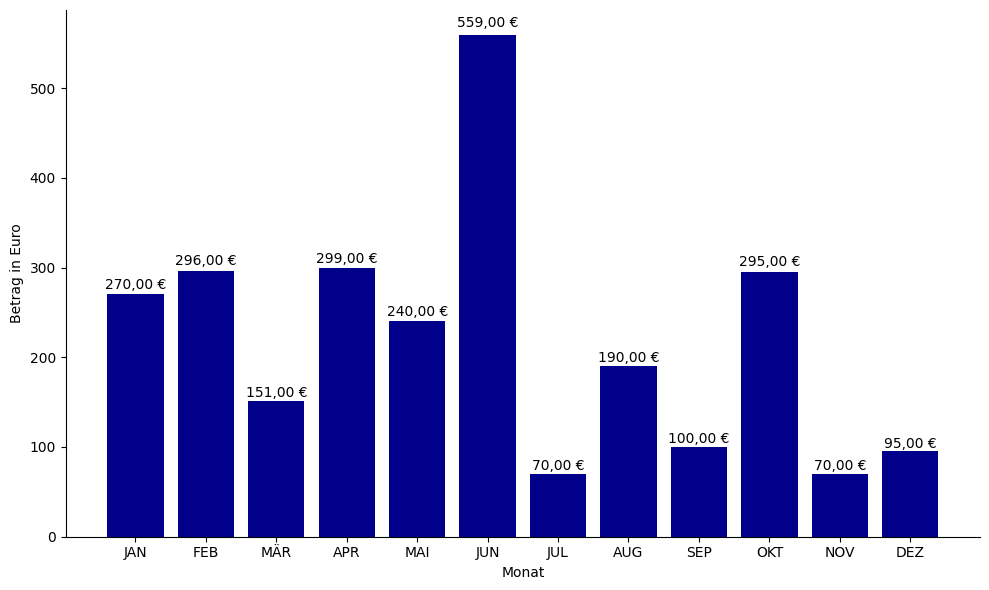

In [102]:
df = Finanzen_Tablepress.copy()

# Letzte 3 Jahre
#df = df[df['Jahr'] >= df['Jahr'].max() - 2]

# Monate bilden und Einnahmen über alle 3 Jahre summieren
einnahmen_monat = (
    df.groupby(df['Datum'].dt.month)['Einnahme']
    .sum()
)

# Sicherstellen, dass M1 bis M12 vorhanden sind
einnahmen_monat = einnahmen_monat.reindex([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], fill_value=0)

# Beschriftungen
labels = ['JAN', 'FEB', 'MÄR', 'APR', 'MAI', 'JUN', 'JUL', 'AUG', 'SEP', 'OKT', 'NOV', 'DEZ']

# Diagramm
fig_Umsatzstärkster_Monat_summe, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels,
    einnahmen_monat,
    color='darkblue'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('Betrag in Euro')
ax.set_xlabel('Monat')

# Werte über den Balken
for bar, wert in zip(bars, einnahmen_monat):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        wert + abs(wert) * 0.01,  # kleiner Abstand zum Balken
        f'{wert:,.2f} €'.replace(',', 'X').replace('.', ',').replace('X', '.'),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [103]:
svg = StringIO()
FigureCanvasSVG(fig_Umsatzstärkster_Monat_summe).print_svg(svg)

with open("Umsatzstärkster_Monat.html", "w", encoding="utf-8") as f:
    f.write(f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Umsatzstärkster_Monat</title>
    </head>
    <body>
        {svg.getvalue()}
    </body>
    </html>
    """)

# Monatsübersicht (letzte 2 Jahre)

Kopie vom Code "Quartalsübersicht" und ersetzen der Werte "Quartal" durch "Monat". Dann kann der Code 1:1 verwendet werden.

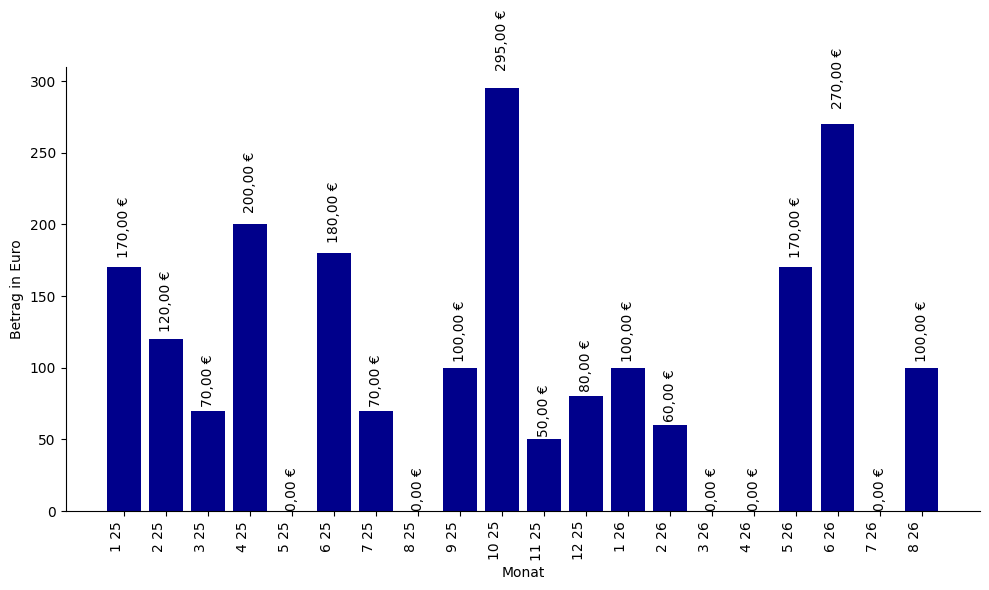

In [104]:
df = Finanzen_Tablepress.copy()

# Letzte 3 Jahr
df = df[df['Jahr'] >= df['Jahr'].max() - 1]

# Monat bilden und Einnahmen summieren
einnahmen = (
    df.groupby([df['Datum'].dt.year, df['Datum'].dt.month])['Einnahme']
    .sum()
)

# Beschriftungen
labels = [f"{month} {str(jahr)[-2:]}" for jahr, month in einnahmen.index]

# Diagramm
fig_Monat, ax = plt.subplots(figsize=(10, 6))
bars = plt.bar(labels, einnahmen, color='darkblue')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.ylabel('Betrag in Euro')
plt.xlabel('Monat')
plt.xticks(rotation=90, ha='right')

# Werte über den Balken
for bar, wert in zip(bars, einnahmen):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        wert + abs(wert) * 0.04,
        f'{wert:,.2f} €'.replace(',', 'X').replace('.', ',').replace('X', '.'),
        ha='center',
        va='bottom',
        rotation=90
    )

plt.tight_layout()
plt.show()

In [105]:
from io import StringIO
from matplotlib.backends.backend_svg import FigureCanvasSVG

svg = StringIO()
FigureCanvasSVG(fig_Monat).print_svg(svg)

with open("Monatsübersicht.html", "w", encoding="utf-8") as f:
    f.write(f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Monatsübersicht</title>
    </head>
    <body>
        {svg.getvalue()}
    </body>
    </html>
    """)

# Umsatzstärkster Verkaufskanal (seit 2024)

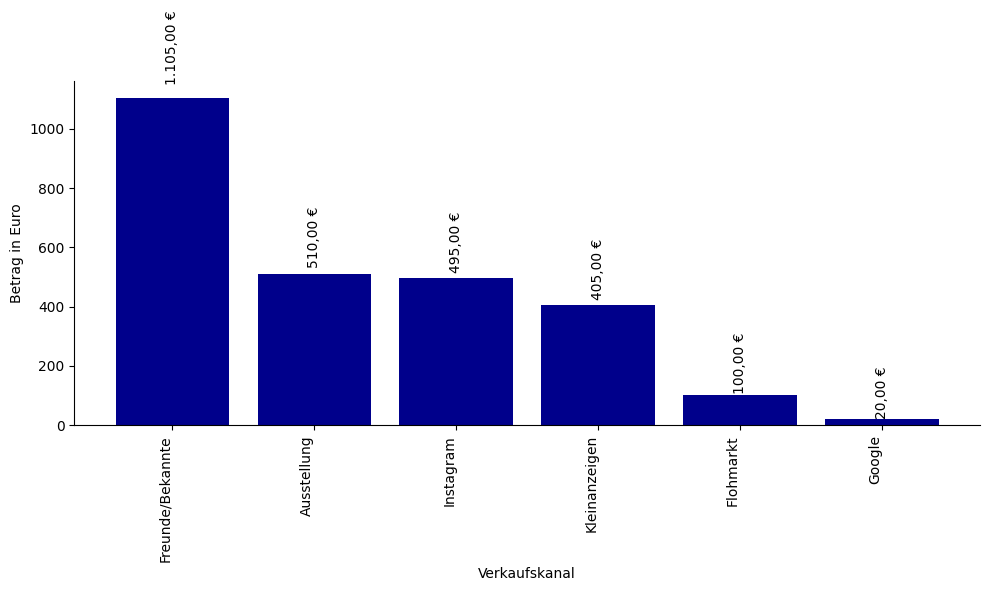

In [106]:
df = Finanzen_Tablepress.copy()

# Nur Kategorie "Einnahmen"
df = df[df['Kategorie'] == 'Einnahmen']

# Monat bilden und Einnahmen summieren
einnahmen = (
    df.groupby([df['Klassifizierung'].astype(str)])['Einnahme']
    .sum()
    .sort_values(ascending=False)
)

# Diagramm
fig_Umsatzstärkster_Verkaufskanal_summe, ax = plt.subplots(figsize=(10, 6))
bars = plt.bar(einnahmen.index, einnahmen, color='darkblue')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.ylabel('Betrag in Euro')
plt.xlabel('Verkaufskanal')
plt.xticks(rotation=90, ha='right')

# Werte über den Balken
for bar, wert in zip(bars, einnahmen):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        wert + abs(wert) * 0.04,
        f'{wert:,.2f} €'.replace(',', 'X').replace('.', ',').replace('X', '.'),
        ha='center',
        va='bottom',
        rotation=90
    )

plt.tight_layout()
plt.show()

In [107]:
svg = StringIO()
FigureCanvasSVG(fig_Umsatzstärkster_Verkaufskanal_summe).print_svg(svg)

with open("Umsatzstärkster_Verkaufskanal.html", "w", encoding="utf-8") as f:
    f.write(f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Umsatzstärkster_Verkaufskanal</title>
    </head>
    <body>
        {svg.getvalue()}
    </body>
    </html>
    """)

# Umsatzstärkster Verkaufskanal (letzte 3 Jahre)

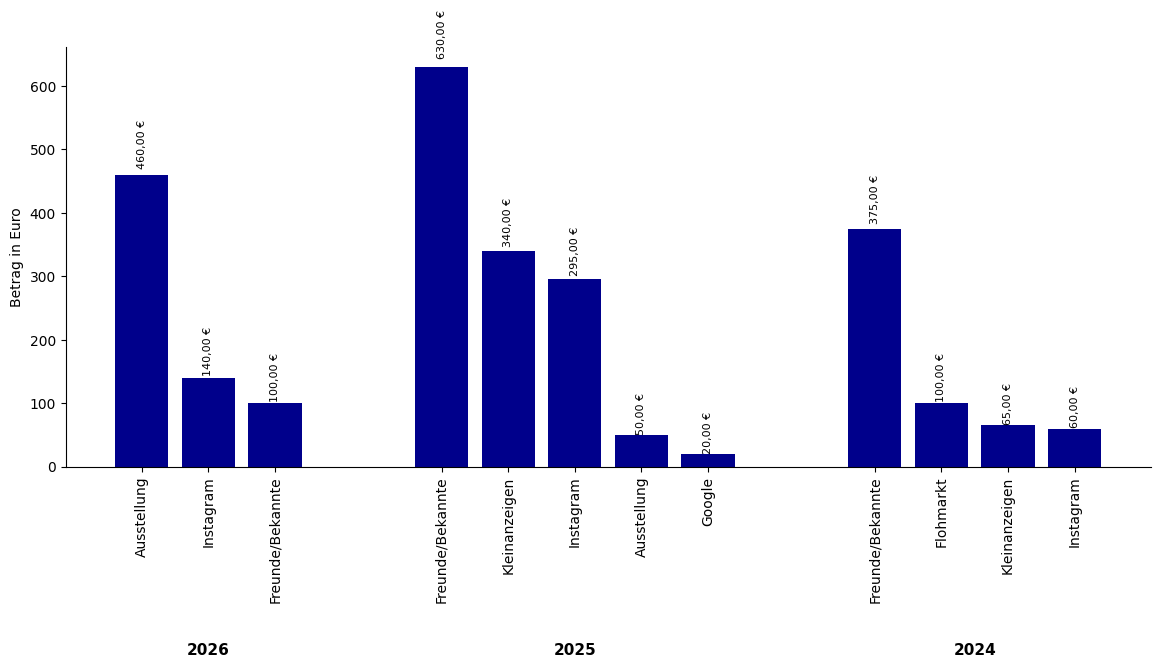

In [108]:
df = Finanzen_Tablepress.copy()

# Nur Kategorie "Einnahmen"
df = df[df['Kategorie'] == 'Einnahmen'].copy()

# Jahr aus Datum bilden
df['Jahr'] = pd.to_datetime(df['Datum']).dt.year

# Letzte 3 Jahre bestimmen
letzte_3_jahre = sorted(
    df['Jahr'].dropna().unique(),
    reverse=True
)[:3]

# Einnahmen nach Jahr und Verkaufskanal summieren
einnahmen = (
    df.groupby(['Jahr', 'Klassifizierung'])['Einnahme']
    .sum()
    .reset_index()
)

# -------------------------------------------------------
# Balken vorbereiten
# -------------------------------------------------------

alle_balken = []

for jahr in letzte_3_jahre:

    # Innerhalb jedes Jahres absteigend sortieren
    daten_jahr = (
        einnahmen[einnahmen['Jahr'] == jahr]
        .sort_values('Einnahme', ascending=False)
    )

    for _, zeile in daten_jahr.iterrows():
        alle_balken.append({
            'Jahr': jahr,
            'Kanal': zeile['Klassifizierung'],
            'Wert': zeile['Einnahme']
        })


# -------------------------------------------------------
# Positionen der Balken
# -------------------------------------------------------

# Abstand zwischen den Jahresgruppen
gruppenabstand = 1.5

x_positionen = []
labels_kanal = []
werte = []

jahr_mittelpunkte = []

aktuelle_position = 0

for jahr in letzte_3_jahre:

    daten_jahr = [
        x for x in alle_balken
        if x['Jahr'] == jahr
    ]

    start_position = aktuelle_position

    for eintrag in daten_jahr:

        x_positionen.append(aktuelle_position)
        labels_kanal.append(str(eintrag['Kanal']))
        werte.append(eintrag['Wert'])

        aktuelle_position += 1

    # Mittelpunkt der Jahresgruppe
    ende_position = aktuelle_position - 1

    jahr_mittelpunkte.append(
        (start_position + ende_position) / 2
    )

    # Abstand zwischen den Jahresgruppen
    aktuelle_position += gruppenabstand


# -------------------------------------------------------
# Diagramm
# -------------------------------------------------------

fig_Umsatzstärkster_Verkaufskanal, ax = plt.subplots(
    figsize=(14, 7)
)

bars = ax.bar(
    x_positionen,
    werte,
    width=0.8,
    color='darkblue'
)


# -------------------------------------------------------
# Werte über den Balken
# -------------------------------------------------------

for bar, wert in zip(bars, werte):

    if wert != 0:

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            wert + abs(wert) * 0.02,
            f'{wert:,.2f} €'
                .replace(',', 'X')
                .replace('.', ',')
                .replace('X', '.'),
            ha='center',
            va='bottom',
            rotation=90,
            fontsize=8
        )


# -------------------------------------------------------
# X-Achse: Verkaufskanäle
# -------------------------------------------------------

ax.set_xticks(x_positionen)

ax.set_xticklabels(
    labels_kanal,
    rotation=90,
    ha='center'
)

#ax.set_xlabel('Verkaufskanal')
ax.set_ylabel('Betrag in Euro')


# -------------------------------------------------------
# Jahre unterhalb der Verkaufskanäle
# -------------------------------------------------------

for jahr, mittelpunkt in zip(
    letzte_3_jahre,
    jahr_mittelpunkte
):

    ax.text(
        mittelpunkt,
        -0.42,
        str(jahr),
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='top',
        fontsize=11,
        fontweight='bold'
    )


# -------------------------------------------------------
# Optik
# -------------------------------------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Unterhalb der X-Achse mehr Platz für die Jahre
plt.subplots_adjust(bottom=0.28)

plt.show()

In [109]:
svg = StringIO()
FigureCanvasSVG(fig_Umsatzstärkster_Verkaufskanal).print_svg(svg)

with open("Umsatzstärkster_Verkaufskanal_pro_Jahr.html", "w", encoding="utf-8") as f:
    f.write(f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Umsatzstärkster_Verkaufskanal_pro_Jahr</title>
    </head>
    <body>
        {svg.getvalue()}
    </body>
    </html>
    """)

# Umsatzstärkste Ausstellung (seit 2024)

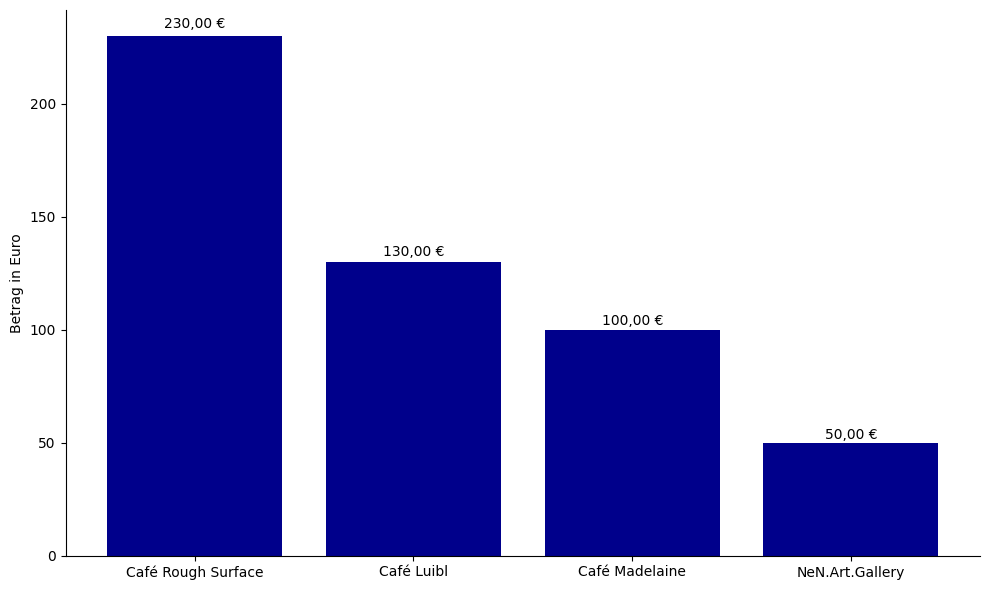

In [110]:
import re

df = Finanzen_Tablepress.copy()

# Nur Klassifizierung "Ausstellung" und Kategorie "Einnahmen"
df = df[
    (df['Klassifizierung'] == 'Ausstellung') &
    (df['Kategorie'] == 'Einnahmen')
]

# Monate bilden und Einnahmen über alle 3 Jahre summieren
einnahmen_ausstellung = (
    df.groupby(df['Notiz'].astype(str))['Einnahme']
    .sum()
    .sort_values(ascending=False)
)

# X-Achsen-Beschriftungen kürzen:
# Alles inklusive Klammern wird entfernt
labels_kurz = [
    re.sub(r'\s*\(.*?\)', '', str(label)).strip()
    for label in einnahmen_ausstellung.index
]

# Diagramm
fig_Umsatzstärkste_Ausstellung, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels_kurz,
    einnahmen_ausstellung,
    color='darkblue'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('Betrag in Euro')

# Werte über den Balken
for bar, wert in zip(bars, einnahmen_ausstellung):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        wert + abs(wert) * 0.01,
        f'{wert:,.2f} €'
            .replace(',', 'X')
            .replace('.', ',')
            .replace('X', '.'),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [111]:
svg = StringIO()
FigureCanvasSVG(fig_Umsatzstärkste_Ausstellung).print_svg(svg)

with open("Umsatzstärkste_Ausstellung.html", "w", encoding="utf-8") as f:
    f.write(f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Umsatzstärkste_Ausstellung</title>
    </head>
    <body>
        {svg.getvalue()}
    </body>
    </html>
    """)

In [112]:
#name: Weekly Notebook Run

#on:
#  schedule:
#    - cron: '0 8 * * 1'
#  workflow_dispatch:

#permissions:
#  contents: write

#jobs:
#  run-notebook:
#    runs-on: ubuntu-latest

#    steps:
#    - name: Repository auschecken
#      uses: actions/checkout@v3

#    - name: Python installieren
#      uses: actions/setup-python@v4
#      with:
#        python-version: '3.10'
#
#    - name: Abhängigkeiten installieren
#      run: |
#        pip install -r requirements.txt
#        pip install papermill ipykernel

#    - name: Notebook ausführen
#     run: |
#        papermill Datenaufbereitung.ipynb ausgegebenes_notebook.ipynb

#    - name: Plotly-Diagramme als Artefakte speichern
#      uses: actions/upload-artifact@v4
#      with:
#        name: plotly-diagramme
#        path: |
#          Übersicht.html
#          Maße_Tabelle.html
#          Einnahmen_Ausgaben.html
#          Interaktives_Kreisdiagramm.html

#    - name: Änderungen committen und pushen
#      run: |
#        git config --global user.name 'github-actions'
#        git config --global user.email 'github-actions@github.com'
#        git add Übersicht.html Maße_Tabelle.html Einnahmen_Ausgaben.html Interaktives_Kreisdiagramm.html
#        git commit -m "Diagramme für GitHub Pages aktualisiert" || echo "Keine Änderungen zum Commit"
#        git push